In [1]:

import pandas as pd
import numpy as np
import xgboost as xgb
import sklearn
import sys
import os
import matplotlib.pyplot as plt
# 1. Get the absolute path of the folder two levels up (your main project folder)
project_root = os.path.abspath("../../")

# 2. Add that project folder to Python's search path
if project_root not in sys.path:
    sys.path.append(project_root)
import src.features as ft
import src.evaluation as ev

d:\AI\Stock Analysis\trading_system\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
loaded_ranker = xgb.XGBRanker()
loaded_ranker.load_model("../../models/vnindex_ranker_model_monthly.json")

print("Model loaded successfully!")

Model loaded successfully!


In [3]:
FILE_URL = "../../data/market_data.parquet"
df = pd.read_parquet(FILE_URL)
df = df[df["close"] > 0]
df.head()

,date,open,high,low,close,volume,Symbol
0,2017-08-08,4.63,4.65,4.55,4.56,382940,ACB
1,2017-08-09,4.56,4.56,4.46,4.49,1649412,ACB
2,2017-08-10,4.46,4.51,4.44,4.46,1139760,ACB
3,2017-08-11,4.48,4.48,4.44,4.46,774623,ACB
4,2017-08-14,4.44,4.51,4.44,4.51,657975,ACB


In [4]:
df = ft.build_features(df)
df = ft.target_generating_ranking(df)
df.head()

,date,open,high,low,close,volume,Symbol,log_ret_1w,log_ret_1m,log_ret_3m,...,vol_21d_avg,vol_3m_avg,volume_surge_monthly,volume_surge_weekly,RSI_14,next_1m_ret,next_1w_ret,qid,risk_adj_ret,target_quintile
105283,2018-08-07,33.76,34.78,33.70,34.48,29410,PAN,0.059129,0.030168,-0.102732,...,3.742048e+04,4.710921e+04,0.794335,2.184686,52.623381,0.008663,0.010387,0,0.025401,0
152842,2018-08-07,12.27,12.34,12.14,12.14,613455,VGC,0.005721,0.074421,-0.291952,...,1.632681e+06,2.152275e+06,0.758584,0.640552,41.543374,0.114299,0.037191,0,0.194912,2
162416,2018-08-07,1.56,1.56,1.52,1.54,41011,VIX,0.045910,0.159507,0.080043,...,1.459688e+05,1.336584e+05,1.092104,1.113817,59.069197,0.087011,0.000000,0,0.200560,4
9440,2018-08-08,6.54,6.81,6.54,6.59,88440,BSI,-0.016680,0.043757,-0.171045,...,7.727238e+04,9.523667e+04,0.811372,0.622033,49.057782,-0.033954,0.000000,1,-0.097260,0
28392,2018-08-08,5.39,5.54,5.39,5.42,21800,DBC,-0.045542,-0.042111,0.197490,...,2.229505e+04,4.469090e+04,0.498872,0.587888,43.844799,0.195458,0.041560,1,0.406814,4


In [5]:


# Define your features and target
features = [
    'log_ret_1m', 'log_ret_3m', 'log_ret_1y',      # Momentum
    'volatility_shock_monthly', 'volatility_3m',              # Risk
    'dist_SMA_100',                           # Fast Trend
    'RSI_14','volume_surge_monthly'
]



In [6]:

# ==========================================
# PHASE B: PREDICT (Walk-Forward CV)
# ==========================================
# Pass the best_params dictionary directly into your updated WFCV function
honest_test_df = ev.walk_forward_cv(
    df, 
    features, 
    model_params=None, # <--- INJECTION HAPPENS HERE
    initial_train_months=12, 
    test_months=6, 
    gap_days=21
)

# ==========================================
# PHASE C: BACKTEST & PLOT
# ==========================================


# [Paste your exact matplotlib plotting code here to see the final graph]

--- Fold 1 ---
Train: 2018-08-07 to 2019-07-17 (18439 rows)
Test:  2019-08-07 to 2020-02-06 (11170 rows)
--- Fold 2 ---
Train: 2018-08-07 to 2020-01-17 (30005 rows)
Test:  2020-02-07 to 2020-08-06 (11589 rows)
--- Fold 3 ---
Train: 2018-08-07 to 2020-07-17 (41131 rows)
Test:  2020-08-07 to 2021-02-05 (11826 rows)
--- Fold 4 ---
Train: 2018-08-07 to 2021-01-15 (52859 rows)
Test:  2021-02-08 to 2021-08-06 (11215 rows)
--- Fold 5 ---
Train: 2018-08-07 to 2021-07-16 (64074 rows)
Test:  2021-08-09 to 2022-01-28 (11295 rows)
--- Fold 6 ---
Train: 2018-08-07 to 2022-01-17 (75905 rows)
Test:  2022-02-07 to 2022-08-05 (12166 rows)
--- Fold 7 ---
Train: 2018-08-07 to 2022-07-15 (87464 rows)
Test:  2022-08-08 to 2023-02-06 (11931 rows)
--- Fold 8 ---
Train: 2018-08-07 to 2023-01-17 (99973 rows)
Test:  2023-02-07 to 2023-08-04 (12321 rows)
--- Fold 9 ---
Train: 2018-08-07 to 2023-07-17 (111799 rows)
Test:  2023-08-07 to 2024-02-06 (12641 rows)
--- Fold 10 ---
Train: 2018-08-07 to 2024-01-17 (12443

In [7]:
result = ev.run_xgboost_backtest(
    honest_test_df, 
    model=None, 
    features=features,
    time_of_rebalance='M',trailing_stop=-0.10,
    #trend_filter_col='dist_SMA_50'
)

In [8]:
print(result)

         date  total_value       cash  number_of_holdings
0  2019-08-07     9991.180   1171.180                   1
1  2019-09-03    10871.180   1171.180                   1
2  2019-10-01    11562.690   4212.690                   3
3  2019-11-01    11850.670   2190.670                   4
4  2019-12-02    11205.090    676.090                   3
..        ...          ...        ...                 ...
75 2025-11-03    23957.585  11911.585                   3
76 2025-12-01    23817.025  19117.025                   1
77 2026-01-05    23683.059  15943.059                   1
78 2026-02-02    27388.879  11758.879                   2
79 2026-03-02    27464.709   4934.709                   2

[80 rows x 4 columns]


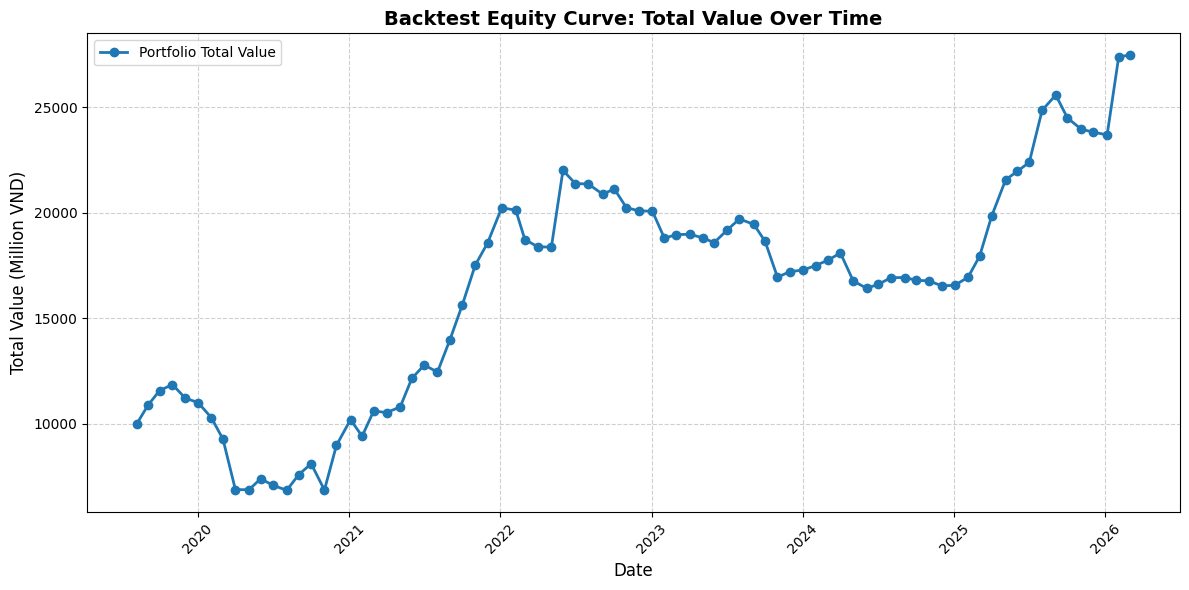

In [9]:
ev.capital_over_time(result)